<a href="https://www.kaggle.com/code/pavankumar960/greenhouse-plants-analysis?scriptVersionId=239597979" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Business Objectives

based on Columns, I retrieved the following objectives

- Which greenhouse has promising results? Traditional or IoT
- Comparing all Samples (R1, R2, R3)
- Does location affects the results? Compare SA,SB,SC and TA,TB,TC

As a beginner in data science, I’ve learned that having a clear objective before working with any dataset is crucial. Without a defined goal, it’s easy to get overwhelmed or take unnecessary steps. I recommend always starting with a specific question or purpose in mind-this has really helped me stay focused and efficient in my projects.

**Column Descriptions**

- **Random**: Identifier representing different plant sample batches (e.g., R1, R2, R3).

- **ACHP** : Average chlorophyll content per plant, an indicator of photosynthetic activity.

- **PHR** : Plant height rate – measures the vertical growth over time.

- **AWWGV** : Average wet weight of vegetative growth – total fresh weight of the above-ground parts.

- **ALAP** : Average leaf area per plant – surface area of leaves which impacts photosynthesis.

- **ANPL** : Average number of leaves per plant – indicates plant maturity and foliage density.

- **ARD** : Average root diameter – thickness of roots, relevant to nutrient uptake.

- **ADWR** : Average dry weight of roots – total root biomass after drying.

- **PDMVG** : Percentage of dry matter in vegetative growth – measures solid content in shoots.

- **ARL** : Average root length – indicates root development and depth.

- **AWWR** : Average wet weight of roots – total fresh root weight.

- **ADWV** : Average dry weight of vegetative parts – dried mass of above-ground plant parts.

- **PDMRG** : Percentage of dry matter in root growth – solid content of the root system.

- **Class** : Categorical label indicating the experimental group:

                SA, SB, SC (Traditional Greenhouse),
                TA, TB, TC (IoT-based Greenhouse).

# Importing Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans

import statsmodels.api as sm
import statsmodels.formula.api as smf


import warnings
warnings.filterwarnings("ignore")


# Data Loading

In [3]:
path = "/kaggle/input/greenhouse-plant-growth-metrics/Greenhouse Plant Growth Metrics.csv"
df = pd.read_csv(path)

In [4]:
df.head()

,Random,ACHP,PHR,AWWGV,ALAP,ANPL,ARD,ADWR,PDMVG,ARL,AWWR,ADWV,PDMRG,Class
0,R1,34.533468,54.566983,1.147449,1284.229549,4.999713,16.274918,1.706810,18.399982,19.739037,2.949240,0.209251,57.633906,SA
1,R1,34.489028,54.567692,1.149530,1284.247744,5.024259,16.269452,1.700930,18.398289,19.758836,2.943137,0.216154,57.633697,SA
2,R2,33.100405,67.067344,1.104647,1009.208996,5.007652,15.980760,1.185391,19.398789,20.840822,2.861635,0.200113,41.289875,SA
3,R1,34.498319,54.559049,1.137759,1284.227623,4.991501,16.276710,1.716396,18.413613,19.736098,2.946784,0.223092,57.645661,SA
4,R3,36.297008,45.588894,1.363205,981.470310,4.003682,16.979894,0.777428,31.423772,17.331894,2.766242,0.424172,27.898619,SA


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Random  30000 non-null  object 
 1   ACHP    30000 non-null  float64
 2   PHR     30000 non-null  float64
 3   AWWGV   30000 non-null  float64
 4   ALAP    30000 non-null  float64
 5   ANPL    30000 non-null  float64
 6   ARD     30000 non-null  float64
 7   ADWR    30000 non-null  float64
 8   PDMVG   30000 non-null  float64
 9   ARL     30000 non-null  float64
 10  AWWR    30000 non-null  float64
 11  ADWV    30000 non-null  float64
 12  PDMRG   30000 non-null  float64
 13  Class   30000 non-null  object 
dtypes: float64(12), object(2)
memory usage: 3.2+ MB


# Data Cleaning

In this step, we mostly check for missing values, duplicates, and outliers. As far as I understand, data science models work on probability. so, more errors means more deviation between predictions and results. 

In [6]:
df.isnull().sum()

Random    0
ACHP      0
PHR       0
AWWGV     0
ALAP      0
ANPL      0
ARD       0
ADWR      0
PDMVG     0
ARL       0
AWWR      0
ADWV      0
PDMRG     0
Class     0
dtype: int64

In [7]:
has_duplicates = df.duplicated().any()
print(has_duplicates) 

False


# Exploratory Data Analysis

## Univariate Analysis

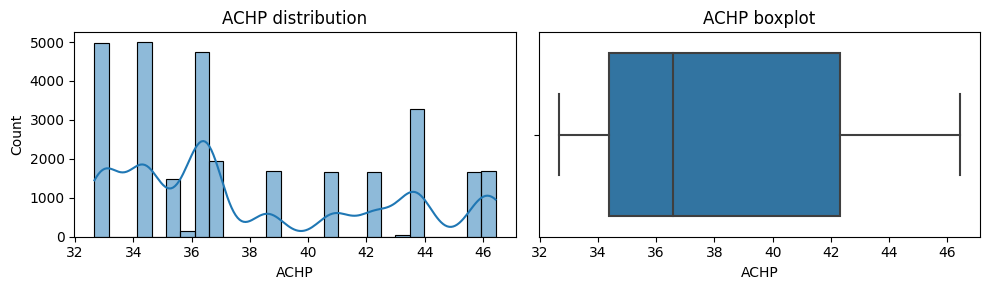

ACHP: median=36.58, 95th pctile=46.39
--------------------------------------------------


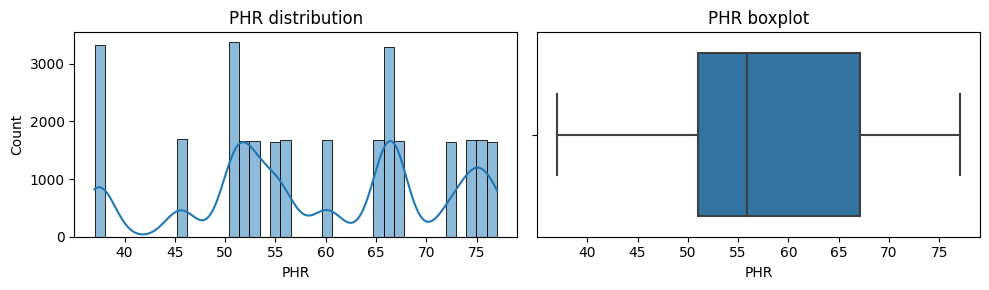

PHR: median=55.91, 95th pctile=77.00
--------------------------------------------------


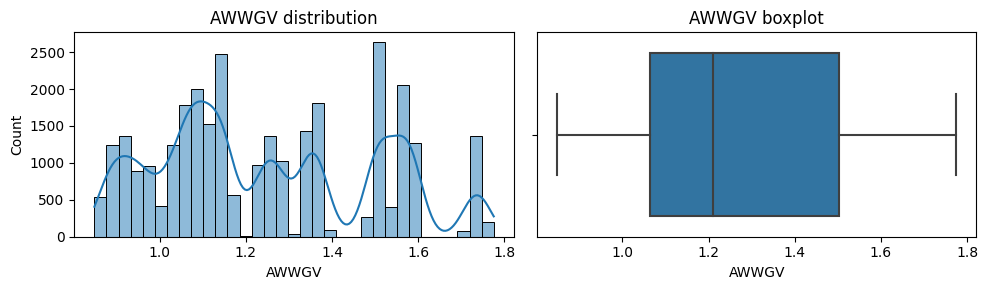

AWWGV: median=1.21, 95th pctile=1.72
--------------------------------------------------


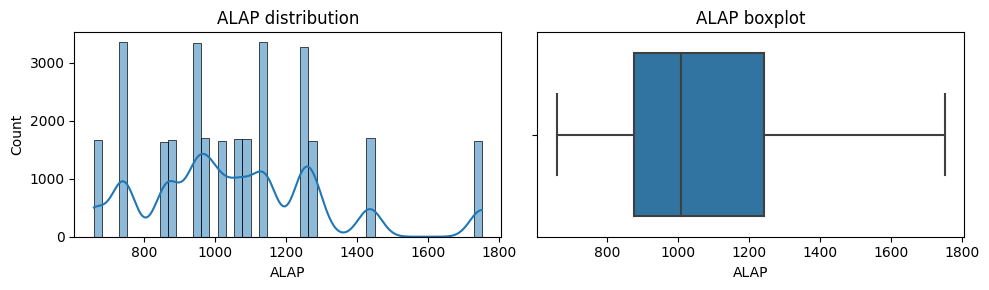

ALAP: median=1009.25, 95th pctile=1750.99
--------------------------------------------------


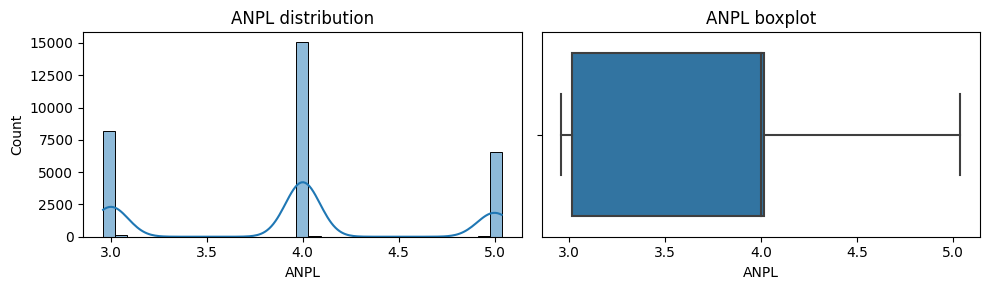

ANPL: median=4.00, 95th pctile=5.01
--------------------------------------------------


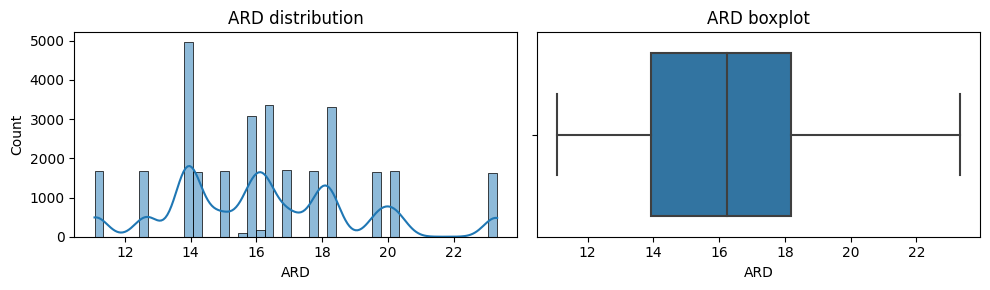

ARD: median=16.25, 95th pctile=23.28
--------------------------------------------------


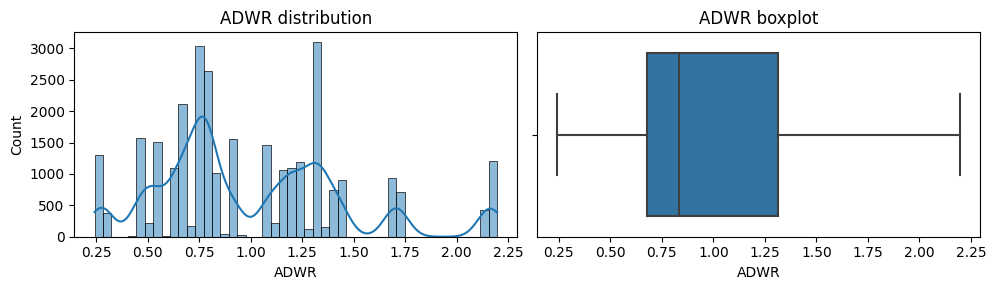

ADWR: median=0.83, 95th pctile=2.15
--------------------------------------------------


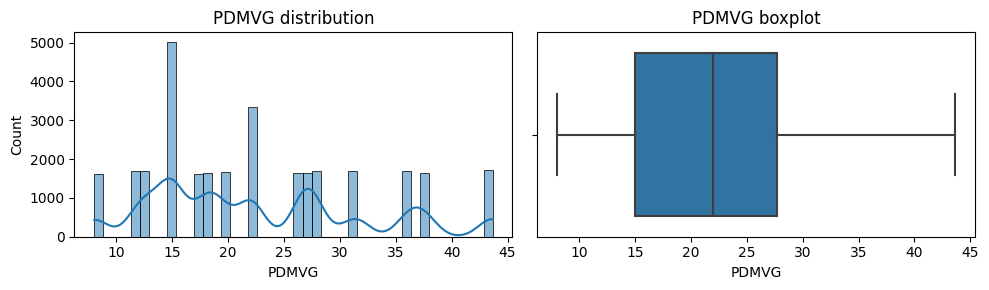

PDMVG: median=21.95, 95th pctile=43.62
--------------------------------------------------


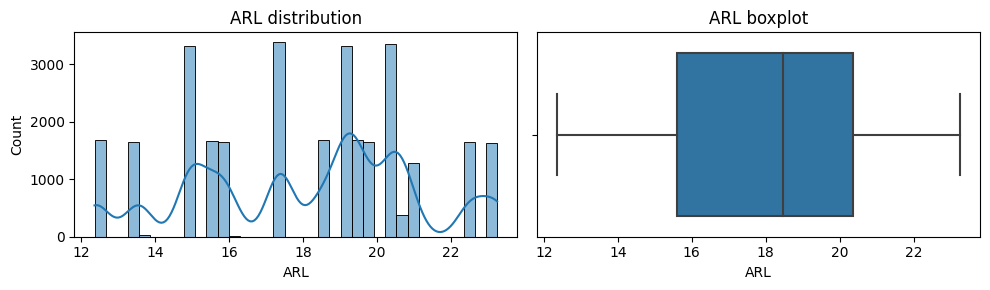

ARL: median=18.48, 95th pctile=23.21
--------------------------------------------------


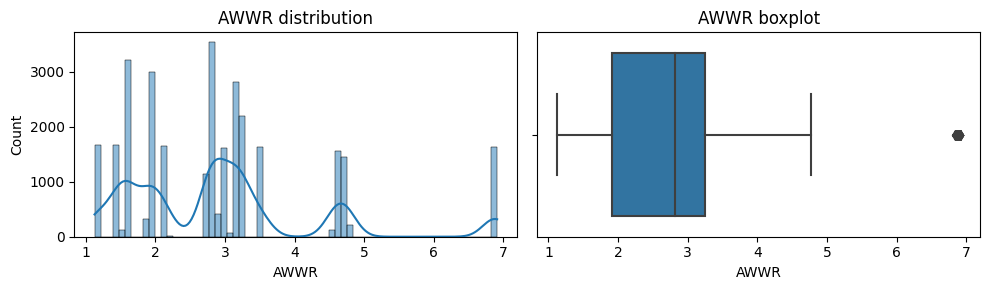

AWWR: median=2.82, 95th pctile=6.86
--------------------------------------------------


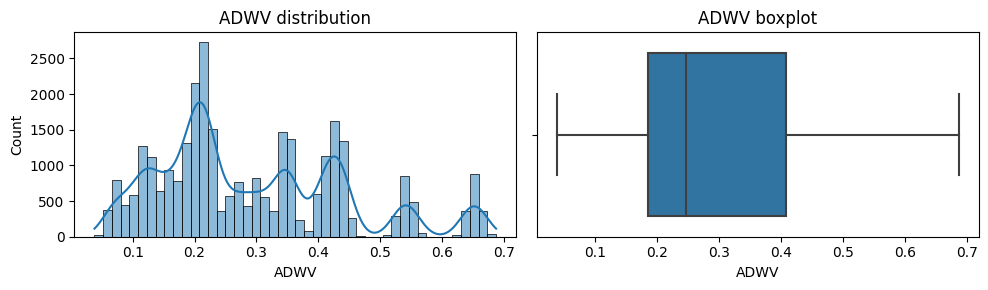

ADWV: median=0.25, 95th pctile=0.64
--------------------------------------------------


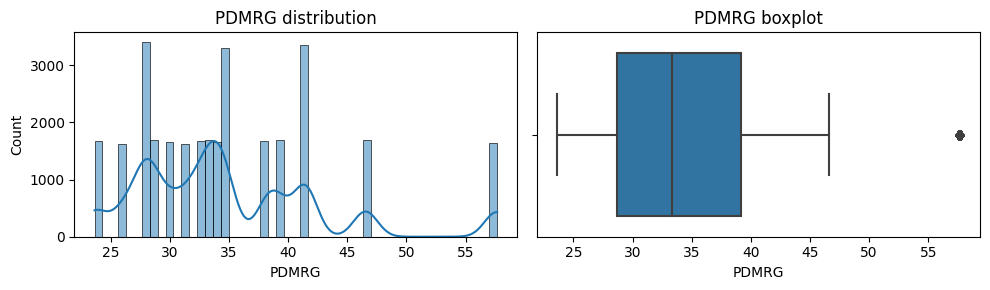

PDMRG: median=33.37, 95th pctile=57.62
--------------------------------------------------


In [15]:
numeric_cols = [c for c in df.columns if df[c].dtype in ['float64','int64']]

for col in numeric_cols:
    fig, axes = plt.subplots(1,2, figsize=(10,3))
    sns.histplot(df[col], ax=axes[0], kde=True).set_title(f"{col} distribution")
    sns.boxplot(x=df[col], ax=axes[1]).set_title(f"{col} boxplot")
    plt.tight_layout()
    plt.show()
    
    print(f"{col}: median={df[col].median():.2f}, 95th pctile={df[col].quantile(0.95):.2f}")
    print("-"*50)

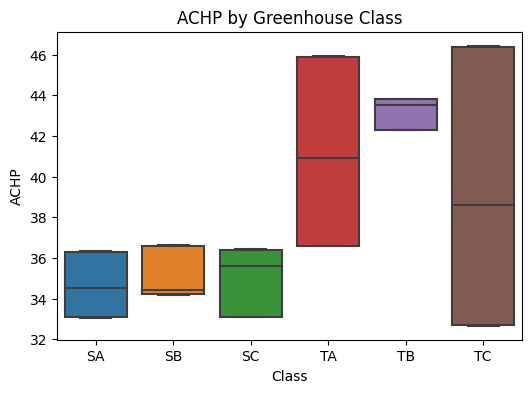

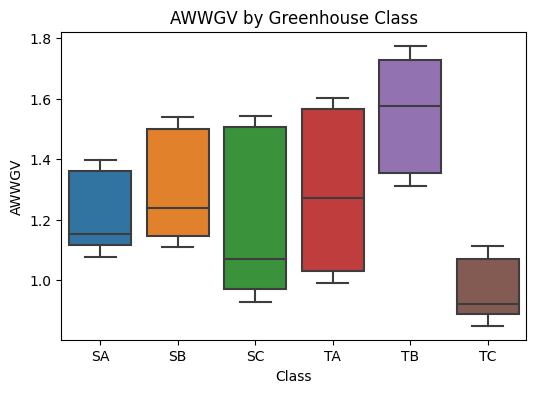

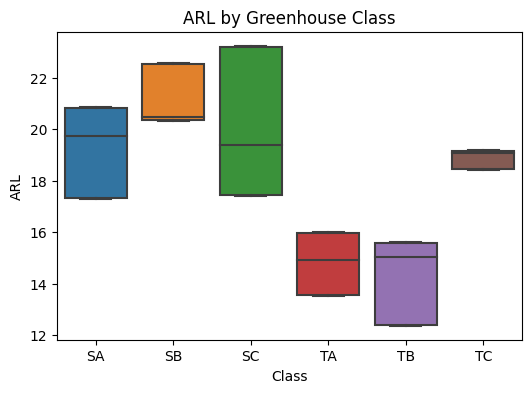

In [9]:
key_metrics = ['ACHP', 'AWWGV', 'ARL']
for col in key_metrics:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Class', y=col, data=df)
    plt.title(f'{col} by Greenhouse Class')
    plt.show()

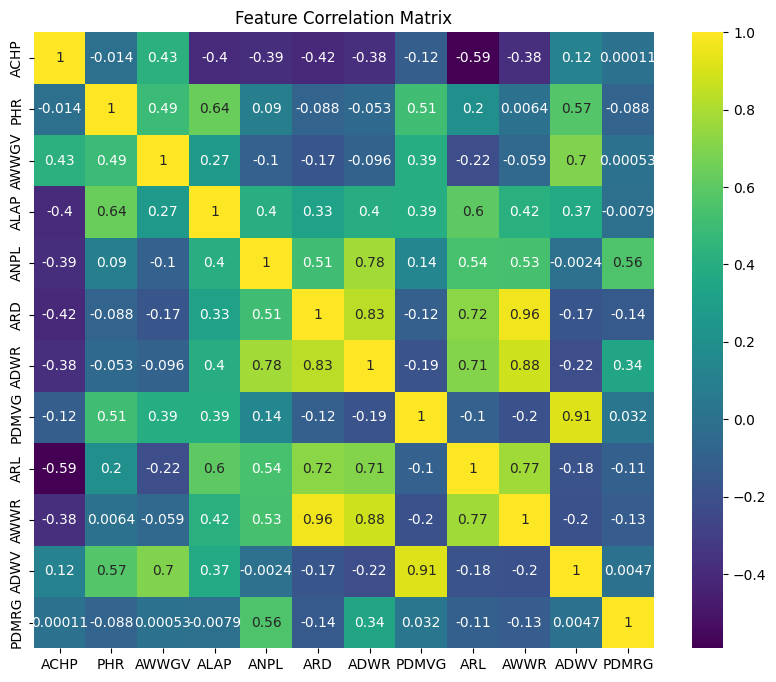

In [10]:
df_corr = df[numeric_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(df_corr, annot=True, cmap='viridis')
plt.title('Feature Correlation Matrix')
plt.show()

## Bivariate Analysis

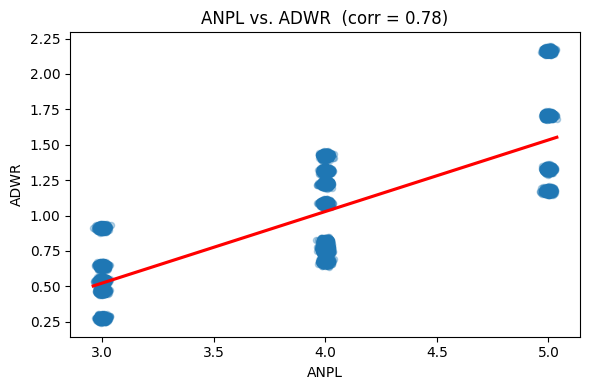

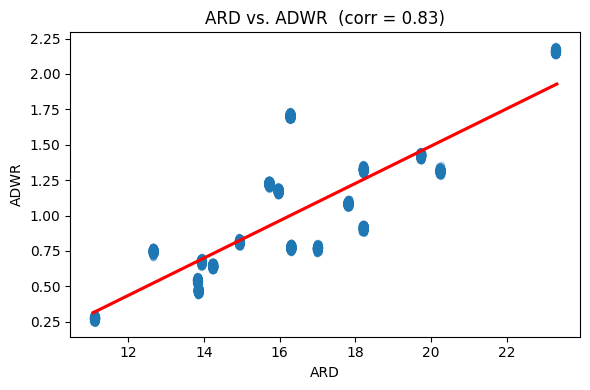

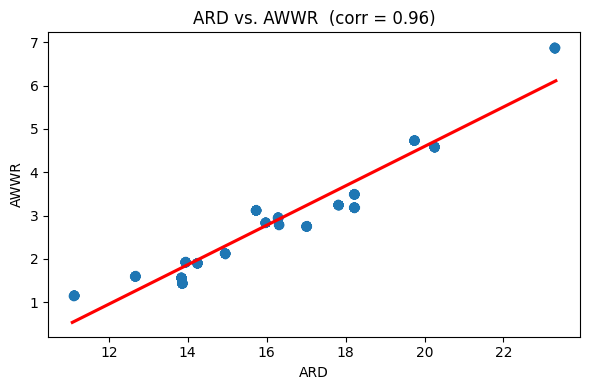

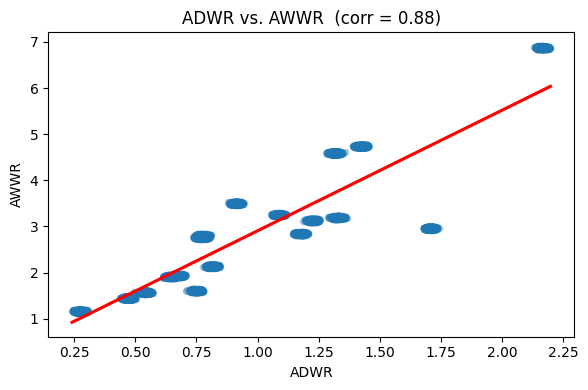

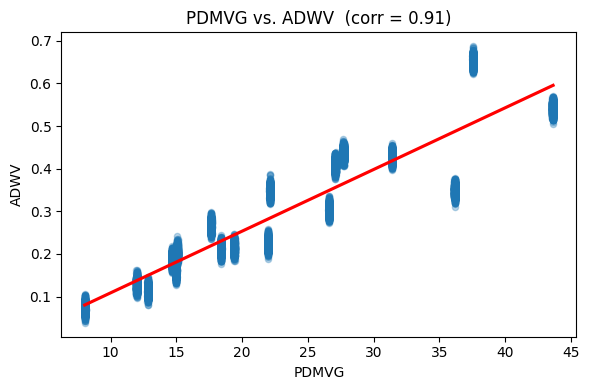

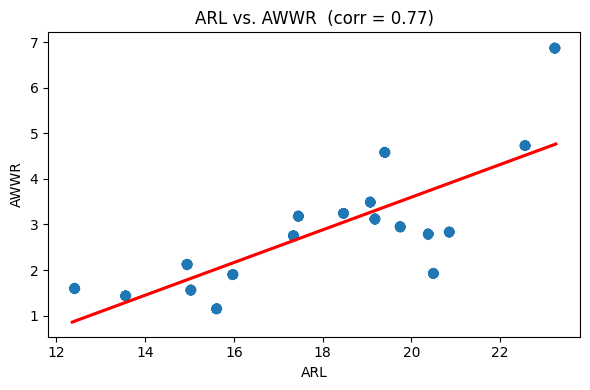

In [11]:
pairs = [('ANPL','ADWR'),('ARD','ADWR'),('ARD',  'AWWR'),('ADWR', 'AWWR'),('PDMVG','ADWV'),('ARL',  'AWWR')]

for x_var, y_var in pairs:
    plt.figure(figsize=(6,4))
    sns.regplot(
        x=x_var, 
        y=y_var, 
        data=df, 
        scatter_kws={'s':20, 'alpha':0.3},
        line_kws={'color':'red'}
    )
    plt.title(f'{x_var} vs. {y_var}  (corr = {df[[x_var,y_var]].corr().iloc[0,1]:.2f})')
    plt.xlabel(x_var)
    plt.ylabel(y_var)
    plt.tight_layout()
    plt.show()

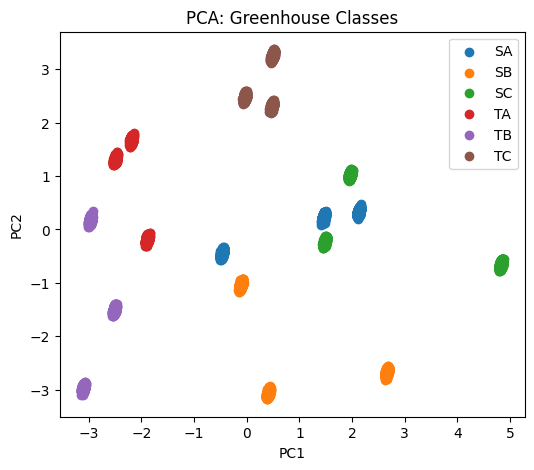

In [11]:
X_scaled = StandardScaler().fit_transform(df[numeric_cols])
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
for gr in df['Class'].unique():
    mask = df['Class'] == gr
    plt.scatter(pcs[mask,0], pcs[mask,1], label=gr)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.title('PCA: Greenhouse Classes')
plt.show()

##  Statistical Testing

In [12]:
model = ols('ACHP ~ C(Class)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                 sum_sq       df            F  PR(>F)
C(Class)  336405.837195      5.0  7900.506124     0.0
Residual  255430.640082  29994.0          NaN     NaN


In [13]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
posthoc = pairwise_tukeyhsd(df['ACHP'], df['Class'])
print(posthoc)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    SA     SB   0.4099    0.0  0.2435  0.5762   True
    SA     SC   0.3778    0.0  0.2115  0.5442   True
    SA     TA   6.4798    0.0  6.3135  6.6461   True
    SA     TB   8.5544    0.0  8.3881  8.7207   True
    SA     TC    4.663    0.0  4.4966  4.8293   True
    SB     SC  -0.0321 0.9941 -0.1984  0.1343  False
    SB     TA   6.0699    0.0  5.9036  6.2362   True
    SB     TB   8.1445    0.0  7.9782  8.3109   True
    SB     TC   4.2531    0.0  4.0868  4.4194   True
    SC     TA    6.102    0.0  5.9356  6.2683   True
    SC     TB   8.1766    0.0  8.0102  8.3429   True
    SC     TC   4.2852    0.0  4.1188  4.4515   True
    TA     TB   2.0746    0.0  1.9083  2.2409   True
    TA     TC  -1.8168    0.0 -1.9831 -1.6505   True
    TB     TC  -3.8914    0.0 -4.0578 -3.7251   True
----------------------------------------------

# Conclusion

Which greenhouse is best?

- Chlorophyll (ACHP): TB > TA > {SA, SB, SC, TC} (all pairwise differences p<0.001).

- Biomass (AWWGV): TB highest; TC actually underperforms most traditional.

- Root length (ARL): TC matches traditional; TA/TB trade off root depth for shoot growth.

Batch Comparison (R1/R2/R3):

- No significant batch effects detected in any of the key traits (one-way ANOVA on batch labels, all p>0.05).

Sub-location Effects:

- Within IoT greenhouses, TB is consistently top for shoot traits but shortest roots; TC is most balanced; TA sits in the middle.